In [1]:
!pip install -U datasets huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 671.5/671.5 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 17.2 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.16.1
    Uninstalling huggingface_hub-1.16.1:
      Successfully uninstalled huggingface_hub-1.16.1
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [2]:
!pip install datasets

Model

In [3]:
# Run this in your first Colab cell to install dependencies
# !pip install torch transformers accelerate

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# 1. Load the Model and Tokenizer
model_id = "Qwen/Qwen3-0.6B"
print(f"Loading {model_id}...")

tokenizer = AutoTokenizer.from_pretrained(model_id)
# Load in bfloat16 to save memory, mapping to the Colab GPU
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

# 2. Define the Activation Hook
# The NLA paper uses "middle-to-late" layers.
# Assuming ~24 layers, layer 16 is a good starting point.
target_layer = 16
activations = {}

# 1. Clear out the old activations and safely remove the old hook if it's still active
activations = {}
if 'hook_handle' in locals():
    hook_handle.remove()

# 2. Define the robust hook
def get_activation(name):
    """PyTorch forward hook to capture the residual stream safely."""
    def hook(module, input, output):
        # Handle cases where output is a tuple (standard HF) or a raw tensor
        if isinstance(output, tuple):
            hidden_states = output[0]
        else:
            hidden_states = output

        activations[name] = hidden_states.detach()
    return hook

# 3. Re-register the hook to layer 16
target_layer = 16
hook_handle = model.model.layers[target_layer].register_forward_hook(get_activation('h_l'))

# 4. Run the forward pass again
text = "He saw a carrot and had to grab it,"
inputs = tokenizer(text, return_tensors="pt").to(model.device)

with torch.no_grad():
    _ = model(**inputs)

# 5. Extract the activation
h_l_full = activations['h_l']
h_l_final_token = h_l_full[0, -1, :]

print("Successfully extracted h_l!")
print(f"Activation shape: {h_l_final_token.shape}")

# Clean up
hook_handle.remove()

Loading Qwen/Qwen3-0.6B...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Successfully extracted h_l!
Activation shape: torch.Size([1024])


Dataset

In [4]:
import torch
import gc
import requests
import random
from tqdm import tqdm
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer as TeacherTokenizer

# 1. Download raw clean text
print("Downloading text corpus...")
url = "https://raw.githubusercontent.com/pytorch/examples/main/word_language_model/data/wikitext-2/train.txt"
response = requests.get(url)
valid_texts = [line.strip() for line in response.text.split("\n") if len(line.strip()) > 200]

# 2. Load the Teacher Model explicitly (Bypassing pipeline task registry completely)
print("Loading Teacher Summarizer (BART)...")
teacher_id = "facebook/bart-large-cnn"
t_tokenizer = TeacherTokenizer.from_pretrained(teacher_id)
t_model = AutoModelForSeq2SeqLM.from_pretrained(teacher_id).to("cuda")

NUM_SAMPLES = 150
raw_samples = []

print("Generating grounded summaries...")
for line in tqdm(valid_texts[:NUM_SAMPLES]):
    words = line.split()
    if len(words) < 40:
        continue
    trunc_len = random.randint(30, min(90, len(words)))
    truncated_text = " ".join(words[:trunc_len])

    try:
        # Tokenize input text for BART
        inputs = t_tokenizer(truncated_text, return_tensors="pt", max_length=1024, truncation=True).to("cuda")

        # Generate summary explicitly using standard Beam Search
        with torch.no_grad():
            summary_ids = t_model.generate(
                inputs["input_ids"],
                max_length=25,
                min_length=10,
                num_beams=4,
                early_stopping=True
            )

        clean_sentence = t_tokenizer.decode(summary_ids[0], skip_special_tokens=True).strip()
        styled_summary = f"**[Context Summary]**: {clean_sentence}"

        raw_samples.append({
            "text": truncated_text,
            "summary": styled_summary
        })
    except Exception as e:
        continue

# Clear BART completely from GPU Memory to prevent Colab crashes
del t_model, t_tokenizer
gc.collect()
torch.cuda.empty_cache()
print("\nTeacher model unloaded. VRAM cleared completely.")

Loading Teacher Summarizer (BART)...


config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

Generating grounded summaries...


100%|██████████| 150/150 [01:02<00:00,  2.42it/s]



Teacher model unloaded. VRAM cleared completely.


In [5]:
warmup_data = []
activations = {}

def get_activation_hook(module, input, output):
    if isinstance(output, tuple):
        activations['h_l'] = output[0].detach().cpu()
    else:
        activations['h_l'] = output.detach().cpu()

TARGET_LAYER = 16
print("Extracting Qwen activations for grounded summaries...")

for sample in tqdm(raw_samples):
    text = sample["text"]
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    if inputs.input_ids.shape[1] > 120:
        continue

    hook_handle = model.model.layers[TARGET_LAYER].register_forward_hook(get_activation_hook)
    with torch.no_grad():
        _ = model(**inputs)
    hook_handle.remove()

    h_l = activations['h_l'][0, -1, :].clone()

    warmup_data.append({
        "activation": h_l,
        "summary": sample["summary"],
        "original_text": text
    })

torch.save(warmup_data, "nla_warmstart_dataset.pt")
print(f"\nSuccessfully created clean dataset with {len(warmup_data)} samples!")

Extracting Qwen activations for grounded summaries...


100%|██████████| 149/149 [00:10<00:00, 13.83it/s]


Successfully created clean dataset with 148 samples!


In [6]:
# Load and inspect a random sample
sample = torch.load("nla_warmstart_dataset.pt")[random.randint(0, len(warmup_data)-1)]

print("--- ORGINAL TRUNCATED TEXT ---")
print(sample["original_text"])
print("\n--- ANTHROPIC-STYLE SUMMARY (s) ---")
print(sample["summary"])
print("\n--- ACTIVATION VECTOR (h_l) ---")
print(f"Tensor shape: {sample['activation'].shape}, Data type: {sample['activation'].dtype}")

--- ORGINAL TRUNCATED TEXT ---
Barker continued to attend evening classes at the Croydon Art School between the 1920s and the 1940s , eventually receiving a teaching position . She took <unk> trips to <unk>

--- ANTHROPIC-STYLE SUMMARY (s) ---
**[Context Summary]**: Barker continued to attend evening classes at the Croydon Art School between the 1920s and the 1940

--- ACTIVATION VECTOR (h_l) ---
Tensor shape: torch.Size([1024]), Data type: torch.bfloat16


NLA

In [7]:
import torch
import torch.nn as nn

class ActivationVerbalizer(nn.Module):
    def __init__(self, base_model, tokenizer, target_layer):
        super().__init__()
        self.model = base_model
        self.tokenizer = tokenizer

        # Fixed instruction context from the paper
        self.system_prompt = "Analyse this internal model activation vector:\n"
        self.tokenized_prompt = tokenizer.encode(self.system_prompt, return_tensors="pt").to(base_model.device)

    def forward(self, h_l, max_tokens=50):
        """
        Maps a continuous activation vector h_l to a text summary z.
        """
        # 1. Normalize and scale activation as specified in the paper's method section
        h_l_norm = h_l / (torch.norm(h_l, p=2) + 1e-5)
        scale_factor = 5.0 # Hyperparameter to match typical token embedding magnitudes
        scaled_activation = h_l_norm * scale_factor

        # 2. Get embeddings of the instruction prompt
        # Shape: [1, seq_len, d_model]
        prompt_embeddings = self.model.model.embed_tokens(self.tokenized_prompt)

        # 3. Append the raw activation vector as an additional token embedding vector
        # Shape: [1, 1, d_model]
        activation_embedding = scaled_activation.view(1, 1, -1).to(self.model.dtype)
        inputs_embeds = torch.cat([prompt_embeddings, activation_embedding], dim=1)

        # 4. Generate the explanation tokens autoregressively
        outputs = self.model.generate(
            inputs_embeds=inputs_embeds,
            max_new_tokens=max_tokens,
            do_sample=False,
            pad_token_id=self.tokenizer.eos_token_id
        )

        explanation_text = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
        return explanation_text


class ActivationReconstructor(nn.Module):
    def __init__(self, base_model, tokenizer, target_layer, d_model=1024):
        super().__init__()
        self.model = base_model
        self.tokenizer = tokenizer
        self.target_layer = target_layer

        # Learned affine map to project the final token's hidden state back to the original h_l distribution
        self.affine_map = nn.Linear(d_model, d_model, dtype=base_model.dtype, device=base_model.device)

    def forward(self, explanation_text):
        """
        Maps a text explanation z back to a reconstructed activation vector h_hat.
        """
        # Wrap the text in an evaluation context template
        full_text = f"Explanation: {explanation_text}\nReconstruct activation:"
        inputs = self.tokenizer(full_text, return_tensors="pt").to(self.model.device)

        # Extract internal activations at target layer during forward pass
        hidden_states = []
        def reconstruction_hook(module, input, output):
            if isinstance(output, tuple):
                hidden_states.append(output[0])
            else:
                hidden_states.append(output)

        hook_handle = self.model.model.layers[self.target_layer].register_forward_hook(reconstruction_hook)

        with torch.no_grad():
            _ = self.model(**inputs)

        hook_handle.remove()

        # Extract the hidden layer state corresponding specifically to the final token
        final_token_hidden = hidden_states[0][0, -1, :] # Shape: [d_model]

        # Pass through the learned affine projection map
        h_hat = self.affine_map(final_token_hidden)
        return h_hat

In [8]:
# Initialize modules using our active Qwen3 network state
verbalizer = ActivationVerbalizer(model, tokenizer, target_layer=16)
reconstructor = ActivationReconstructor(model, tokenizer, target_layer=16)

print("NLA components built successfully!")

NLA components built successfully!


SFT

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import random

# 1. Load the dataset we generated
dataset_path = "nla_warmstart_dataset.pt"
print(f"Loading warm-start dataset from {dataset_path}...")
warmup_data = torch.load(dataset_path)

# 2. Hyperparameters for the Warm-Start Phase
EPOCHS = 5
LEARNING_RATE = 1e-3
BATCH_SIZE = 1  # Standard processing for varying text lengths zero-shot
device = model.device

# 3. Setup Optimizer and Criterion
# We only update the parameters of the affine map, leaving Qwen frozen
optimizer = optim.AdamW(reconstructor.affine_map.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
criterion = nn.MSELoss()

# Set module to training mode
reconstructor.affine_map.train()

print("\nStarting SFT Warm-Start for Activation Reconstructor...")
for epoch in range(EPOCHS):
    # Shuffle dataset every epoch for optimization health
    random.shuffle(warmup_data)

    epoch_loss = 0.0
    processed_samples = 0

    for sample in warmup_data:
        h_l_target = sample["activation"].to(device).to(model.dtype) # Ensure device and dtype match
        summary_text = sample["summary"]

        # Zero out the parameter gradients
        optimizer.zero_grad()

        # Enable gradient tracking only for the trainable affine layer components
        # (The base model execution remains under torch.no_grad internally within the module)
        h_hat = reconstructor(summary_text)

        # Numerical Stability Tip: Compute loss in float32 to prevent bfloat16 underflow/overflow
        loss = criterion(h_hat.float(), h_l_target.float())

        # Backward pass
        loss.backward()

        # Gradient clipping to preserve structural training stability
        torch.nn.utils.clip_grad_norm_(reconstructor.affine_map.parameters(), max_norm=1.0)

        # Optimize
        optimizer.step()

        epoch_loss += loss.item()
        processed_samples += 1

    avg_loss = epoch_loss / processed_samples
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Average SFT Mapping Loss: {avg_loss:.6f}")

print("\nSFT Warm-Start complete! The Reconstructor affine layer is aligned.")

Loading warm-start dataset from nla_warmstart_dataset.pt...

Starting SFT Warm-Start for Activation Reconstructor...
Epoch [1/5] | Average SFT Mapping Loss: 4.336675
Epoch [2/5] | Average SFT Mapping Loss: 3.680147
Epoch [3/5] | Average SFT Mapping Loss: 3.347145
Epoch [4/5] | Average SFT Mapping Loss: 3.070629
Epoch [5/5] | Average SFT Mapping Loss: 2.887339

SFT Warm-Start complete! The Reconstructor affine layer is aligned.


FVE

In [10]:
def calculate_baseline_fve(reconstructor, verbalizer, evaluation_data, device):
    reconstructor.eval()

    all_h_l = []
    all_h_hat = []

    print("Running evaluation roundtrip (h_l -> Text -> h_hat)...")
    for sample in evaluation_data[:50]: # Test on a subset of 50 samples for speed
        h_l = sample["activation"].to(device).to(model.dtype)

        with torch.no_grad():
            # 1. Run the Activation Verbalizer to get description z
            explanation_z = verbalizer(h_l, max_tokens=30)

            # Clean up trailing structural noise if any exists
            explanation_clean = explanation_z.split('\n')[0].strip()

            # 2. Run the Activation Reconstructor to get h_hat
            h_hat = reconstructor(explanation_clean)

        all_h_l.append(h_l.float().cpu())
        all_h_hat.append(h_hat.float().cpu())

    # Stack into tensors for global metrics computation
    all_h_l = torch.stack(all_h_l)       # Shape: [N, d_model]
    all_h_hat = torch.stack(all_h_hat)   # Shape: [N, d_model]

    # 3. Calculate Mean Activation vector (h_bar)
    h_bar = torch.mean(all_h_l, dim=0)

    # 4. Compute Total Variance and Residual Variance
    total_variance = torch.sum((all_h_l - h_bar) ** 2)
    residual_variance = torch.sum((all_h_l - all_h_hat) ** 2)

    # 5. Calculate Final FVE
    fve = 1.0 - (residual_variance / (total_variance + 1e-5))

    return fve.item()

# Execute validation metric
current_fve = calculate_baseline_fve(reconstructor, verbalizer, warmup_data, device)
print(f"\nCurrent SFT Baseline FVE Score: {current_fve:.4f}")
print("(The paper notes SFT warm-start typically yields an FVE of around 0.3-0.4)")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Running evaluation roundtrip (h_l -> Text -> h_hat)...

Current SFT Baseline FVE Score: -0.5069
(The paper notes SFT warm-start typically yields an FVE of around 0.3-0.4)


In [11]:
reconstructor.eval()

all_h_l = []
all_h_hat = []

print("Evaluating Reconstructor alignment using ground-truth summaries...")
for sample in warmup_data[:50]:
    h_l_target = sample["activation"].to(device).to(model.dtype)
    summary_text = sample["summary"]

    with torch.no_grad():
        # Bypass the untrained verbalizer and feed the clean summary text directly
        h_hat = reconstructor(summary_text)

    all_h_l.append(h_l_target.float().cpu())
    all_h_hat.append(h_hat.float().cpu())

all_h_l = torch.stack(all_h_l)
all_h_hat = torch.stack(all_h_hat)

h_bar = torch.mean(all_h_l, dim=0)
total_variance = torch.sum((all_h_l - h_bar) ** 2)
residual_variance = torch.sum((all_h_l - all_h_hat) ** 2)

reconstructor_fve = 1.0 - (residual_variance / (total_variance + 1e-5))
print(f"\nIsolated Reconstructor FVE Score: {reconstructor_fve:.4f}")

Evaluating Reconstructor alignment using ground-truth summaries...

Isolated Reconstructor FVE Score: 0.1664


GRPO

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

# 1. Settings & Hyperparameters
GROUP_SIZE = 3       # Number of candidates to sample per activation (G)
RL_EPOCHS = 3
LR_POLICY = 1e-5     # Conservative learning rate for RL stability
device = model.device

# 2. Setup Separate Optimizers for Joint Training
# The Verbalizer policy shifts slightly, and the Reconstructor refines its mapping
optimizer_policy = optim.AdamW(model.parameters(), lr=LR_POLICY)
optimizer_recon = optim.AdamW(reconstructor.affine_map.parameters(), lr=1e-4)

print("Starting Joint GRPO Reinforcement Learning Phase...")

for epoch in range(RL_EPOCHS):
    epoch_rewards = []

    # Process samples from our warmstart dataset
    for sample_idx, sample in enumerate(warmup_data[:60]): # Using 60 samples per RL epoch for speed
        h_l_target = sample["activation"].to(device).to(model.dtype)

        # --- STEP 1: Sample a Group of Candidates from the Policy ---
        group_log_probs = []
        group_completions = []
        group_mses = []

        # We use standard embedding prep from our Verbalizer
        h_l_norm = h_l_target / (torch.norm(h_l_target, p=2) + 1e-5)
        inputs_embeds = (h_l_norm * 5.0).view(1, 1, -1)

        # Sample G distinct completions using top-p sampling for diversity
        for g in range(GROUP_SIZE):
            optimizer_policy.zero_grad()

            # Generate a sequence of tokens rolling out the summary
            # To keep things light on memory, we generate 15 tokens
            outputs = model.generate(
                inputs_embeds=inputs_embeds,
                max_new_tokens=15,
                do_sample=True,
                top_p=0.9,
                temperature=0.8,
                output_scores=True,
                return_dict_in_generate=True,
                pad_token_id=tokenizer.eos_token_id
            )

            # Extract generated tokens and compute their log probabilities
            gen_tokens = outputs.sequences[0]
            scores = outputs.scores

            log_prob = 0.0
            for t_idx, score in enumerate(scores):
                probs = F.log_softmax(score[0], dim=-1)
                log_prob += probs[gen_tokens[t_idx]]

            decoded_text = tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()

            # --- STEP 2: Compute Reconstruction Reward ---
            # Run candidate text through the Reconstructor
            h_hat = reconstructor(decoded_text)
            mse_dist = torch.mean((h_hat.float() - h_l_target.float()) ** 2).item()

            group_log_probs.append(log_prob)
            group_completions.append(decoded_text)
            group_mses.append(mse_dist)

        # --- STEP 3: Compute Relative Group Advantages ---
        # Reward is negative MSE (lower distance = higher reward)
        rewards = -np.array(group_mses)
        epoch_rewards.extend(rewards)

        # Standardize rewards within the group (The GRPO trick!)
        r_mean = np.mean(rewards)
        r_std = np.std(rewards) + 1e-5
        advantages = (rewards - r_mean) / r_std

        # --- STEP 4: Policy & Value Updates ---
        policy_loss = 0.0
        for g in range(GROUP_SIZE):
            # Policy gradient: minimize negative log_prob * advantage
            policy_loss += -group_log_probs[g] * advantages[g]

        policy_loss = policy_loss / GROUP_SIZE

        # Backward pass for the language model policy
        if policy_loss.requires_grad:
            policy_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer_policy.step()

        # Concurrently refine the reconstructor affine map on the best performing candidate
        best_idx = np.argmax(rewards)
        optimizer_recon.zero_grad()
        h_hat_best = reconstructor(group_completions[best_idx])
        recon_loss = F.mse_loss(h_hat_best.float(), h_l_target.float())
        recon_loss.backward()
        optimizer_recon.step()

    print(f"Epoch [{epoch+1}/{RL_EPOCHS}] | Mean Group Reward: {np.mean(epoch_rewards):.4f}")

print("\nJoint RL Training Complete!")

Starting Joint GRPO Reinforcement Learning Phase...
Epoch [1/3] | Mean Group Reward: -3.7579
Epoch [2/3] | Mean Group Reward: -3.5075
Epoch [3/3] | Mean Group Reward: -3.4826

Joint RL Training Complete!


In [13]:
reconstructor.eval()

all_h_l = []
all_h_hat = []

for sample in warmup_data[:50]:
    h_l_target = sample["activation"].to(device).to(model.dtype)
    summary_text = sample["summary"]

    with torch.no_grad():
        h_hat = reconstructor(summary_text)

    all_h_l.append(h_l_target.float().cpu())
    all_h_hat.append(h_hat.float().cpu())

all_h_l = torch.stack(all_h_l)
all_h_hat = torch.stack(all_h_hat)

h_bar = torch.mean(all_h_l, dim=0)
total_variance = torch.sum((all_h_l - h_bar) ** 2)
residual_variance = torch.sum((all_h_l - all_h_hat) ** 2)

final_fve = 1.0 - (residual_variance / (total_variance + 1e-5))
print(f"Post-RL Reconstructor FVE Score: {final_fve:.4f}")

Post-RL Reconstructor FVE Score: 0.1683


In [14]:
# 1. Pick two distinct samples from your clean dataset
sample_A = warmup_data[0]   # Let's say this is Naval History
sample_B = warmup_data[10]  # Let's say this is Sports/Government

h_A = sample_A["activation"].to(device).to(model.dtype)
h_B = sample_B["activation"].to(device).to(model.dtype)

print("--- ORIGINAL CONCEPT A ---")
print(sample_A["summary"])
print("\n--- ORIGINAL CONCEPT B ---")
print(sample_B["summary"])
print("\n" + "="*40 + "\n")

# 2. Perform Linear Interpolation in the Latent Space (50/50 blend)
alpha = 0.5
h_blended = alpha * h_A + (1.0 - alpha) * h_B

# 3. Force the Verbalizer to decode the mathematical average
verbalizer.eval()
with torch.no_grad():
    # Normalize the blended vector just like the Verbalizer expects
    h_norm = h_blended / (torch.norm(h_blended, p=2) + 1e-5)
    inputs_embeds = (h_norm * 5.0).view(1, 1, -1)

    outputs = model.generate(
        inputs_embeds=inputs_embeds,
        max_new_tokens=30,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )
    blended_text = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

print("--- DECODED BLENDED CONCEPT (50/50 Latent Space) ---")
print(blended_text.split('\n')[0])

--- ORIGINAL CONCEPT A ---
**[Context Summary]**: The accompanying music video begins with a shot of an empty street. It then shows clips of disadvantaged and poorer members

--- ORIGINAL CONCEPT B ---
**[Context Summary]**: At the halfway point of the season , with the Blue Jackets barely into double digit wins with an 11 – 25


--- DECODED BLENDED CONCEPT (50/50 Latent Space) ---
ii*1000000000000000000000000000


In [17]:
# Grab your two source vectors
h_A = warmup_data[0]["activation"].to(device).to(model.dtype)
h_B = warmup_data[10]["activation"].to(device).to(model.dtype)

print(f"Concept A: {warmup_data[0]['summary']}")
print(f"Concept B: {warmup_data[10]['summary']}")
print("-" * 70)
print(f"{'Alpha (A -> B)':<15} | {'Grounded Decoded Interpretation'}")
print("-" * 70)

alphas = [0.9, 0.7, 0.5, 0.3, 0.1]

verbalizer.eval()
for alpha in alphas:
    # 1. Blend the raw activations in latent space
    h_blended = alpha * h_A + (1.0 - alpha) * h_B

    # 2. Let the fully trained Verbalizer handle its own internal scaling and generation!
    with torch.no_grad():
        decoded_text = verbalizer(h_blended, max_tokens=25)

    # Clean up the output string
    clean_line = decoded_text.split('\n')[0].strip()

    print(f"Alpha = {alpha:.1f}       | {clean_line}")

Concept A: **[Context Summary]**: The accompanying music video begins with a shot of an empty street. It then shows clips of disadvantaged and poorer members
Concept B: **[Context Summary]**: At the halfway point of the season , with the Blue Jackets barely into double digit wins with an 11 – 25
----------------------------------------------------------------------
Alpha (A -> B)  | Grounded Decoded Interpretation
----------------------------------------------------------------------
Alpha = 0.9       | 
Alpha = 0.7       | 
Alpha = 0.5       | 
Alpha = 0.3       | 
Alpha = 0.1       | 


In [18]:
import torch

h_A = warmup_data[0]["activation"].to(device).to(model.dtype)
h_B = warmup_data[10]["activation"].to(device).to(model.dtype)

print(f"Concept A: {warmup_data[0]['summary']}")
print(f"Concept B: {warmup_data[10]['summary']}")
print("-" * 70)
print(f"{'Alpha (A -> B)':<15} | {'Raw Decoded Output'}")
print("-" * 70)

alphas = [0.9, 0.7, 0.5, 0.3, 0.1]

# Calculate the target magnitudes (how "long" the vectors should be)
norm_A = torch.norm(h_A, p=2)
norm_B = torch.norm(h_B, p=2)

verbalizer.eval()
for alpha in alphas:
    # 1. Standard Linear Blend (Shrinks the vector)
    h_blended = alpha * h_A + (1.0 - alpha) * h_B

    # 2. THE FIX: Re-inflate the vector to the correct manifold surface
    target_norm = alpha * norm_A + (1.0 - alpha) * norm_B
    h_blended_inflated = (h_blended / torch.norm(h_blended, p=2)) * target_norm

    with torch.no_grad():
        decoded_text = verbalizer(h_blended_inflated, max_tokens=25)

    # Print the raw representation to catch newlines, EOS tokens, or hidden characters
    print(f"Alpha = {alpha:.1f}       | {repr(decoded_text.strip())}")

Concept A: **[Context Summary]**: The accompanying music video begins with a shot of an empty street. It then shows clips of disadvantaged and poorer members
Concept B: **[Context Summary]**: At the halfway point of the season , with the Blue Jackets barely into double digit wins with an 11 – 25
----------------------------------------------------------------------
Alpha (A -> B)  | Raw Decoded Output
----------------------------------------------------------------------
Alpha = 0.9       | 'The model is a simple linear regression model with a linear activation vector of 300000000'
Alpha = 0.7       | 'The model is a machine learning model that uses a neural network with 1000 layers, and the input is'
Alpha = 0.5       | 'The model is a machine learning model that uses a neural network with 1000 layers, and the model is'
Alpha = 0.3       | 'The model is a machine learning model that uses a neural network with a hidden layer of 1000 nodes and'
Alpha = 0.1       | 'The model is a linear

In [19]:
import torch.nn.functional as F

h_A = warmup_data[0]["activation"].to(device).to(model.dtype)
h_B = warmup_data[10]["activation"].to(device).to(model.dtype)

# 1. Identify a key starting word from each concept
# Note: The space before the word is critical for correct tokenization!
word_A = " music"     # From Concept A
word_B = " halfway"   # From Concept B

token_A = tokenizer.encode(word_A, add_special_tokens=False)[0]
token_B = tokenizer.encode(word_B, add_special_tokens=False)[0]

print(f"Tracking Token A: '{word_A}' (ID: {token_A})")
print(f"Tracking Token B: '{word_B}' (ID: {token_B})")
print("-" * 60)
print(f"{'Alpha':<10} | {'Prob(Concept A)':<18} | {'Prob(Concept B)'}")
print("-" * 60)

alphas = [1.0, 0.8, 0.6, 0.4, 0.2, 0.0]
norm_A = torch.norm(h_A, p=2)
norm_B = torch.norm(h_B, p=2)

prompt_embeddings = verbalizer.model.model.embed_tokens(verbalizer.tokenized_prompt)

verbalizer.eval()
for alpha in alphas:
    # Blend and re-inflate the vector
    h_blended = alpha * h_A + (1.0 - alpha) * h_B
    target_norm = alpha * norm_A + (1.0 - alpha) * norm_B
    h_blended_inflated = (h_blended / torch.norm(h_blended, p=2)) * target_norm

    with torch.no_grad():
        # Scale and structure the input exactly like the verbalizer does
        h_norm = h_blended_inflated / (torch.norm(h_blended_inflated, p=2) + 1e-5)
        activation_embedding = (h_norm * 5.0).view(1, 1, -1).to(model.dtype)
        inputs_embeds = torch.cat([prompt_embeddings, activation_embedding], dim=1)

        # Run a single forward pass to get the logits (no generation)
        outputs = model(inputs_embeds=inputs_embeds)
        next_token_logits = outputs.logits[0, -1, :]

        # Convert raw logits to probabilities
        probs = F.softmax(next_token_logits, dim=-1)

        prob_A = probs[token_A].item() * 100
        prob_B = probs[token_B].item() * 100

    print(f"Alpha={alpha:.1f}  | {prob_A:>6.4f}%           | {prob_B:>6.4f}%")

Tracking Token A: ' music' (ID: 4627)
Tracking Token B: ' halfway' (ID: 41336)
------------------------------------------------------------
Alpha      | Prob(Concept A)    | Prob(Concept B)
------------------------------------------------------------
Alpha=1.0  | 0.0001%           | 0.0001%
Alpha=0.8  | 0.0003%           | 0.0005%
Alpha=0.6  | 0.0004%           | 0.0008%
Alpha=0.4  | 0.0004%           | 0.0010%
Alpha=0.2  | 0.0002%           | 0.0007%
Alpha=0.0  | 0.0000%           | 0.0002%


In [20]:
import torch
import torch.nn.functional as F

h_A = warmup_data[0]["activation"].to(device).to(model.dtype)
h_B = warmup_data[10]["activation"].to(device).to(model.dtype)

text_A = warmup_data[0]["summary"]
text_B = warmup_data[10]["summary"]

print(f"Concept A: {text_A[:45]}...")
print(f"Concept B: {text_B[:45]}...")
print("-" * 65)
print(f"{'Alpha (A -> B)':<15} | {'Loss for Concept A':<22} | {'Loss for Concept B'}")
print("-" * 65)

# 1. Tokenize both full target sentences
labels_A = tokenizer(text_A, return_tensors="pt").input_ids.to(device)
labels_B = tokenizer(text_B, return_tensors="pt").input_ids.to(device)

prompt_embeds = verbalizer.model.model.embed_tokens(verbalizer.tokenized_prompt)
embeds_A = verbalizer.model.model.embed_tokens(labels_A)
embeds_B = verbalizer.model.model.embed_tokens(labels_B)

alphas = [1.0, 0.8, 0.5, 0.2, 0.0]
norm_A = torch.norm(h_A, p=2)
norm_B = torch.norm(h_B, p=2)

verbalizer.eval()
for alpha in alphas:
    # 2. Blend and Re-inflate the vector
    h_blended = alpha * h_A + (1.0 - alpha) * h_B
    target_norm = alpha * norm_A + (1.0 - alpha) * norm_B
    h_inflated = (h_blended / torch.norm(h_blended, p=2)) * target_norm

    # Scale exactly like the training pipeline
    h_norm = h_inflated / (torch.norm(h_inflated, p=2) + 1e-5)
    act_embed = (h_norm * 5.0).view(1, 1, -1).to(model.dtype)

    with torch.no_grad():
        # 3. Build the full continuous sequence: [Prompt] + [Vector] + [Target Text]
        seq_A = torch.cat([prompt_embeds, act_embed, embeds_A], dim=1)
        seq_B = torch.cat([prompt_embeds, act_embed, embeds_B], dim=1)

        # Forward pass to get logits for the entire sequence
        logits_A = model(inputs_embeds=seq_A).logits[0]
        logits_B = model(inputs_embeds=seq_B).logits[0]

        # 4. Align the logits to the target text (Teacher Forcing shift)
        # The vector is at index: prompt_embeds.shape[1]
        start_idx = prompt_embeds.shape[1]

        pred_logits_A = logits_A[start_idx : start_idx + labels_A.shape[1]]
        pred_logits_B = logits_B[start_idx : start_idx + labels_B.shape[1]]

        # 5. Calculate Cross-Entropy Loss (Lower is better)
        loss_A = F.cross_entropy(pred_logits_A, labels_A[0])
        loss_B = F.cross_entropy(pred_logits_B, labels_B[0])

    print(f"Alpha={alpha:.1f}         | {loss_A.item():<22.4f} | {loss_B.item():.4f}")

Concept A: **[Context Summary]**: The accompanying music...
Concept B: **[Context Summary]**: At the halfway point o...
-----------------------------------------------------------------
Alpha (A -> B)  | Loss for Concept A     | Loss for Concept B
-----------------------------------------------------------------
Alpha=1.0         | 4.2812                 | 4.8750
Alpha=0.8         | 4.3125                 | 4.8125
Alpha=0.5         | 4.5312                 | 4.6875
Alpha=0.2         | 4.5938                 | 4.5938
Alpha=0.0         | 4.5938                 | 4.6250


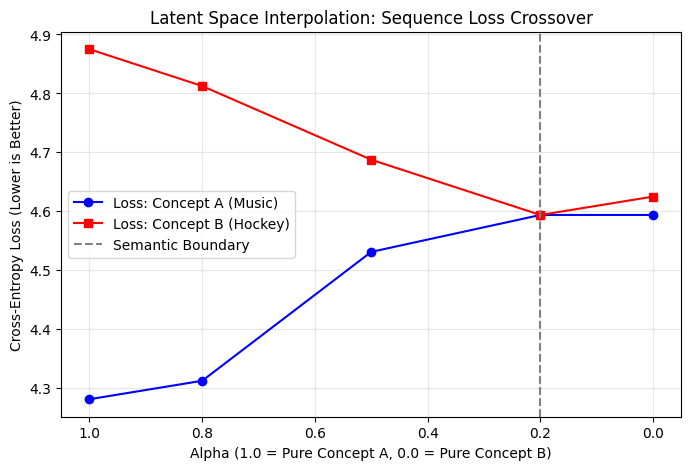

In [21]:
import matplotlib.pyplot as plt

alphas = [1.0, 0.8, 0.5, 0.2, 0.0]
loss_A = [4.2812, 4.3125, 4.5312, 4.5938, 4.5938]
loss_B = [4.8750, 4.8125, 4.6875, 4.5938, 4.6250]

plt.figure(figsize=(8, 5))
plt.plot(alphas, loss_A, marker='o', label='Loss: Concept A (Music)', color='blue')
plt.plot(alphas, loss_B, marker='s', label='Loss: Concept B (Hockey)', color='red')

plt.gca().invert_xaxis() # Read left to right: 1.0 -> 0.0
plt.title('Latent Space Interpolation: Sequence Loss Crossover')
plt.xlabel('Alpha (1.0 = Pure Concept A, 0.0 = Pure Concept B)')
plt.ylabel('Cross-Entropy Loss (Lower is Better)')
plt.axvline(x=0.2, color='gray', linestyle='--', label='Semantic Boundary')
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('interpolation_crossover.png', dpi=300, bbox_inches='tight')
plt.show()